In [1]:
# ==========================================
# Smart City Traffic Forecasting
# ==========================================

# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/train_aWnotuB.csv")

df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [3]:
# ==========================================
# Dataset Information
# ==========================================

print("Shape of Dataset:", df.shape)

print("\nColumns")

print(df.columns)

print("\nDataset Information")

df.info()

Shape of Dataset: (48120, 4)

Columns
Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='str')

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   DateTime  48120 non-null  str  
 1   Junction  48120 non-null  int64
 2   Vehicles  48120 non-null  int64
 3   ID        48120 non-null  int64
dtypes: int64(3), str(1)
memory usage: 2.3 MB


In [4]:
# ==========================================
# Missing Values
# ==========================================

print(df.isnull().sum())

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


In [5]:
# ==========================================
# Statistical Summary
# ==========================================

df.describe()

,Junction,Vehicles,ID
count,48120.000000,48120.000000,4.812000e+04
mean,2.180549,22.791334,2.016330e+10
std,0.966955,20.750063,5.944854e+06
min,1.000000,1.000000,2.015110e+10
25%,1.000000,9.000000,2.016042e+10
50%,2.000000,15.000000,2.016093e+10
75%,3.000000,29.000000,2.017023e+10
max,4.000000,180.000000,2.017063e+10


In [6]:
# ==========================================
# Convert DateTime
# ==========================================

df["DateTime"] = pd.to_datetime(df["DateTime"])

df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [7]:
# ==========================================
# Feature Engineering
# ==========================================

df["Year"] = df["DateTime"].dt.year

df["Month"] = df["DateTime"].dt.month

df["Day"] = df["DateTime"].dt.day

df["Hour"] = df["DateTime"].dt.hour

df["DayOfWeek"] = df["DateTime"].dt.dayofweek

df.head()

,DateTime,Junction,Vehicles,ID,Year,Month,Day,Hour,DayOfWeek
0,2015-11-01 00:00:00,1,15,20151101001,2015,11,1,0,6
1,2015-11-01 01:00:00,1,13,20151101011,2015,11,1,1,6
2,2015-11-01 02:00:00,1,10,20151101021,2015,11,1,2,6
3,2015-11-01 03:00:00,1,7,20151101031,2015,11,1,3,6
4,2015-11-01 04:00:00,1,9,20151101041,2015,11,1,4,6


In [8]:
print(df.columns)

Index(['DateTime', 'Junction', 'Vehicles', 'ID', 'Year', 'Month', 'Day',
       'Hour', 'DayOfWeek'],
      dtype='str')


In [9]:
# ==========================================
# Check Duplicate Rows
# ==========================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


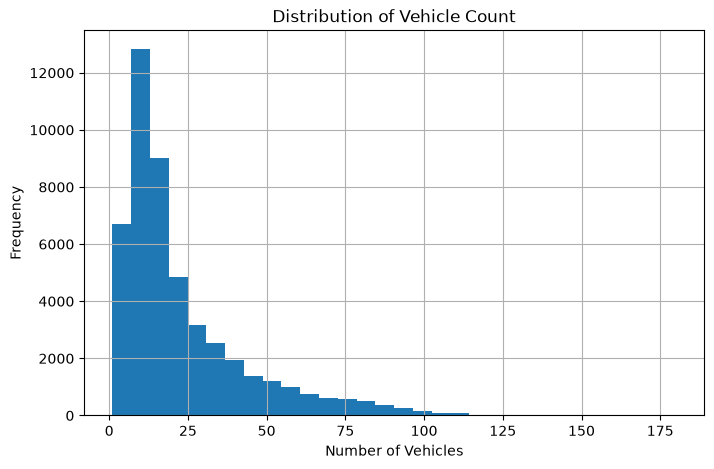

In [10]:
# ==========================================
# Vehicle Distribution
# ==========================================

plt.figure(figsize=(8,5))

plt.hist(df["Vehicles"], bins=30)

plt.title("Distribution of Vehicle Count")

plt.xlabel("Number of Vehicles")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

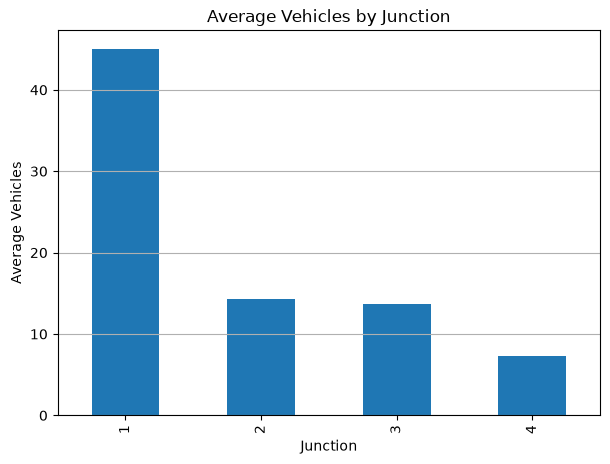

In [11]:
# ==========================================
# Vehicles by Junction
# ==========================================

plt.figure(figsize=(7,5))

df.groupby("Junction")["Vehicles"].mean().plot(kind="bar")

plt.title("Average Vehicles by Junction")

plt.xlabel("Junction")

plt.ylabel("Average Vehicles")

plt.grid(axis="y")

plt.show()

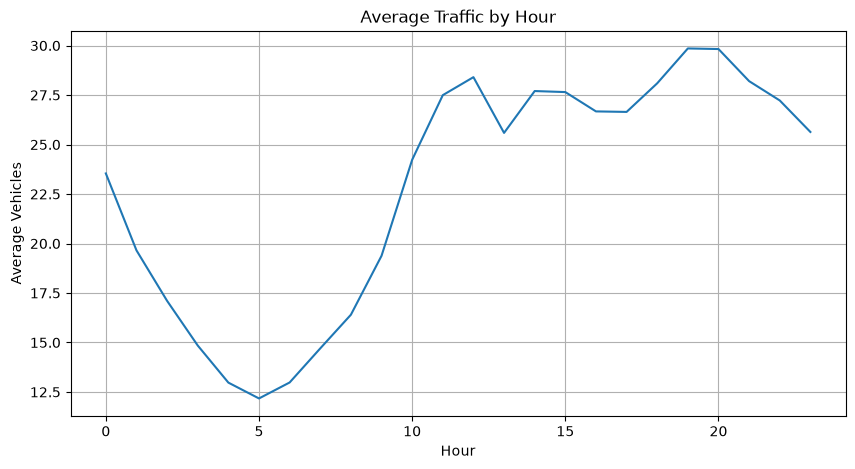

In [12]:
# ==========================================
# Traffic by Hour
# ==========================================

plt.figure(figsize=(10,5))

df.groupby("Hour")["Vehicles"].mean().plot()

plt.title("Average Traffic by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Vehicles")

plt.grid(True)

plt.show()

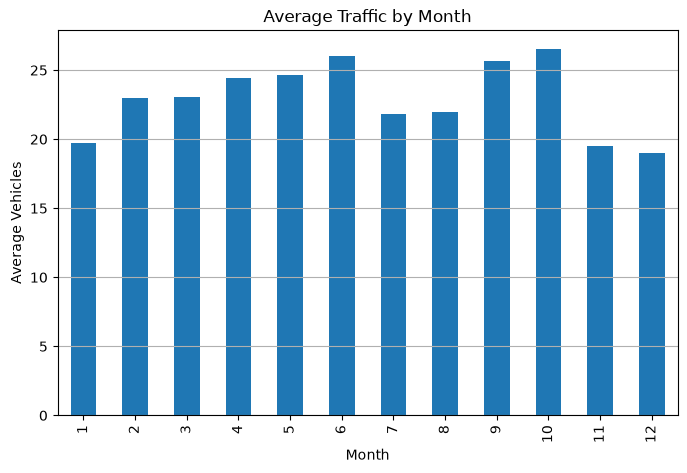

In [13]:
# ==========================================
# Traffic by Month
# ==========================================

plt.figure(figsize=(8,5))

df.groupby("Month")["Vehicles"].mean().plot(kind="bar")

plt.title("Average Traffic by Month")

plt.xlabel("Month")

plt.ylabel("Average Vehicles")

plt.grid(axis="y")

plt.show()

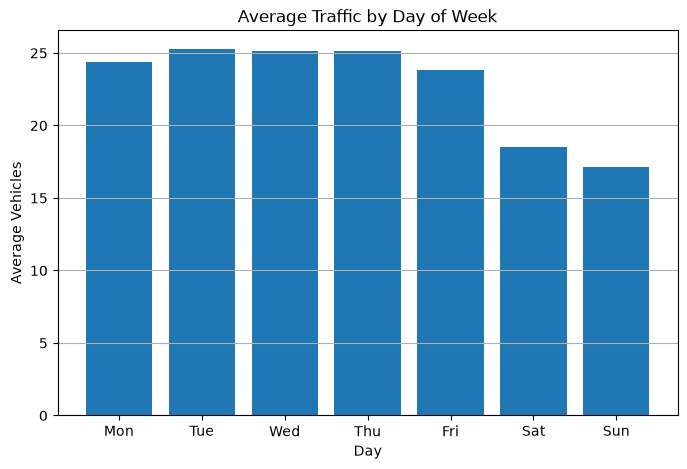

In [14]:
# ==========================================
# Traffic by Day of Week
# ==========================================

plt.figure(figsize=(8,5))

days = [
    "Mon",
    "Tue",
    "Wed",
    "Thu",
    "Fri",
    "Sat",
    "Sun"
]

traffic = df.groupby("DayOfWeek")["Vehicles"].mean()

plt.bar(days, traffic)

plt.title("Average Traffic by Day of Week")

plt.xlabel("Day")

plt.ylabel("Average Vehicles")

plt.grid(axis="y")

plt.show()

In [15]:
# ==========================================
# Correlation Matrix
# ==========================================

correlation = df.corr(numeric_only=True)

print(correlation)

               Junction  Vehicles        ID          Year         Month  \
Junction   1.000000e+00 -0.613787  0.221876  2.212977e-01 -1.242771e-01   
Vehicles  -6.137872e-01  1.000000  0.227974  2.212531e-01 -2.272345e-02   
ID         2.218756e-01  0.227974  1.000000  9.988958e-01 -5.860949e-01   
Year       2.212977e-01  0.221253  0.998896  1.000000e+00 -6.234957e-01   
Month     -1.242771e-01 -0.022723 -0.586095 -6.234957e-01  1.000000e+00   
Day       -2.094621e-03  0.027895 -0.005719 -7.474779e-03  9.154760e-03   
Hour      -2.132575e-15  0.219938  0.000012  7.732006e-16  4.953278e-16   
DayOfWeek -6.590970e-04 -0.126027  0.001131  1.278526e-03 -3.208219e-03   

                    Day          Hour     DayOfWeek  
Junction  -2.094621e-03 -2.132575e-15 -6.590970e-04  
Vehicles   2.789498e-02  2.199377e-01 -1.260265e-01  
ID        -5.719135e-03  1.164412e-05  1.131069e-03  
Year      -7.474779e-03  7.732006e-16  1.278526e-03  
Month      9.154760e-03  4.953278e-16 -3.208219e-03  


In [16]:
# ==========================================
# Feature Selection
# ==========================================

X = df.drop(columns=["DateTime", "Vehicles", "ID"])

y = df["Vehicles"]

print("Features Shape:", X.shape)

print("Target Shape:", y.shape)

X.head()

Features Shape: (48120, 6)
Target Shape: (48120,)


,Junction,Year,Month,Day,Hour,DayOfWeek
0,1,2015,11,1,0,6
1,1,2015,11,1,1,6
2,1,2015,11,1,2,6
3,1,2015,11,1,3,6
4,1,2015,11,1,4,6


In [17]:
# ==========================================
# Train Test Split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)

print("Testing Data :", X_test.shape)

Training Data: (38496, 6)
Testing Data : (9624, 6)


In [18]:
# ==========================================
# Linear Regression Model
# ==========================================

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_prediction = lr_model.predict(X_test)

In [19]:
# ==========================================
# Linear Regression Performance
# ==========================================

lr_mae = mean_absolute_error(y_test, lr_prediction)

lr_mse = mean_squared_error(y_test, lr_prediction)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_prediction)

print("========== Linear Regression Performance ==========")

print(f"Mean Absolute Error (MAE)      : {lr_mae:.2f}")

print(f"Mean Squared Error (MSE)       : {lr_mse:.2f}")

print(f"Root Mean Squared Error (RMSE) : {lr_rmse:.2f}")

print(f"R² Score                       : {lr_r2:.4f}")

========== Linear Regression Performance ==========
Mean Absolute Error (MAE)      : 9.64
Mean Squared Error (MSE)       : 163.12
Root Mean Squared Error (RMSE) : 12.77
R² Score                       : 0.5997


In [20]:
# ==========================================
# Decision Tree Model
# ==========================================

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_prediction = dt_model.predict(X_test)

In [21]:
# ==========================================
# Decision Tree Performance
# ==========================================

dt_mae = mean_absolute_error(y_test, dt_prediction)

dt_mse = mean_squared_error(y_test, dt_prediction)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(y_test, dt_prediction)

print("========== Decision Tree Performance ==========")

print(f"Mean Absolute Error (MAE)      : {dt_mae:.2f}")

print(f"Mean Squared Error (MSE)       : {dt_mse:.2f}")

print(f"Root Mean Squared Error (RMSE) : {dt_rmse:.2f}")

print(f"R² Score                       : {dt_r2:.4f}")

========== Decision Tree Performance ==========
Mean Absolute Error (MAE)      : 3.14
Mean Squared Error (MSE)       : 22.98
Root Mean Squared Error (RMSE) : 4.79
R² Score                       : 0.9436


In [22]:
# ==========================================
# Random Forest Model
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_prediction = rf_model.predict(X_test)

In [23]:
# ==========================================
# Random Forest Performance
# ==========================================

rf_mae = mean_absolute_error(y_test, rf_prediction)

rf_mse = mean_squared_error(y_test, rf_prediction)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_prediction)

print("========== Random Forest Performance ==========")

print(f"Mean Absolute Error (MAE)      : {rf_mae:.2f}")

print(f"Mean Squared Error (MSE)       : {rf_mse:.2f}")

print(f"Root Mean Squared Error (RMSE) : {rf_rmse:.2f}")

print(f"R² Score                       : {rf_r2:.4f}")

========== Random Forest Performance ==========
Mean Absolute Error (MAE)      : 2.40
Mean Squared Error (MSE)       : 12.65
Root Mean Squared Error (RMSE) : 3.56
R² Score                       : 0.9690


In [24]:
# ==========================================
# Model Comparison
# ==========================================

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse
    ],
    "R2 Score": [
        lr_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.637676,12.772034,0.599740
1,Decision Tree,3.136118,4.794033,0.943607
2,Random Forest,2.396650,3.556561,0.968963


In [25]:
# ==========================================
# Best Model
# ==========================================

best_model = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

best_model

,Model,MAE,RMSE,R2 Score
2,Random Forest,2.396650,3.556561,0.968963
1,Decision Tree,3.136118,4.794033,0.943607
0,Linear Regression,9.637676,12.772034,0.599740


In [30]:
import joblib

joblib.dump(
    rf_model,
    "../model/traffic_prediction_model.pkl",
    compress=3
)

['../model/traffic_prediction_model.pkl']

In [34]:
# ==========================================
# Load Saved Model
# ==========================================

loaded_model = joblib.load("../model/traffic_prediction_model.pkl")

print("✅ Model Loaded Successfully!")

✅ Model Loaded Successfully!


In [35]:
import os

model_path = "../model/traffic_prediction_model.pkl"   # adjust if needed

size = os.path.getsize(model_path) / (1024 * 1024)

print(f"Model Size: {size:.2f} MB")

Model Size: 44.01 MB
